In [23]:
library(readxl)
library(ggfortify)
library(edgeR)
library(car)

In [24]:
became = data.frame(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés_161lipidesCommuns.xlsx',sheet=1))
miracle = data.frame(read_xlsx('../data/MIRACLE_LipidomicData_161LipidesCommuns.xlsx',sheet=1))

became_newnorm = data.frame(read_xlsx('../data/BECAME1_LipidomicData_161lip_177suj_SANSCV_Norm SI.xlsx',sheet=1))
miracle_newnorm = data.frame(read_xlsx('../data/MIRACLE_LipidomicData_161lip_177suj_SANSCV_Norm SI.xlsx',sheet=1))

became_meta = data.frame(read_xlsx('../data/BECAME1_LipidomicData_lipidesidentifiés_161lipidesCommuns.xlsx',sheet=2))
miracle_meta = data.frame(read_xlsx('../data/MIRACLE_LipidomicData_161LipidesCommuns.xlsx',sheet=2))

New names:
• `ID-LCMS` -> `ID-LCMS...1`
• `ID-LCMS` -> `ID-LCMS...16`


In [25]:
became_num = became[,-c(1:7)]
miracle_num = miracle[,-c(1:7)]


became_tmp = became_meta[,c(1:3)]
miracle_tmp = miracle_meta[,c(1:3)]

colnames(became_tmp) = c('id','group','cluster')
colnames(miracle_tmp) = c('id','group','cluster')

became_tmp$cluster = paste0('B',became_tmp$cluster)
miracle_tmp$cluster = paste0('M',miracle_tmp$cluster)

became_tmp$cohort = 'BECAME'
miracle_tmp$cohort = 'MIRACLE'

meta = rbind(became_tmp,miracle_tmp)
rownames(meta) = paste0('X',meta$id)

In [26]:
dim(miracle)
dim(became)

[1] 161 184

[1] 161 202

In [27]:
rownames(became_tmp) = paste0('X',became_tmp[,1])

In [28]:
# became_num = data.frame(t(became_num))
# for(i in 1:ncol(became_num)){became_num[,i]=as.numeric(became_num[,i])}
# became_num$response_var = as.factor(as.numeric(became_tmp[rownames(became_num),'cluster']=='B1'))
# 
# # Check for multicollinearity using VIF
# vif_values <- vif(glm(response_var ~ ., data = became_num, family = "binomial"))
# 
# # Display VIF values
# print(vif_values)

In [29]:
head(became_num)

,X10299,X10301,X10302,X10303,X10304,X10305,X10306,X10307,X10308,X10309,⋯,X10640,X10641,X10642,X10643,X10644,X10645,X10646,X10647,X10648,X10649
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,222359.25981631,549566.949592114,439619.028825322,606064.63659777,472962.977048045,408060.207042733,555258.847993366,202460.675161532,253441.789948271,100910.187080309,⋯,332129.228973643,110865.777288807,345835.554435005,307069.682726955,264153.430725529,574965.805825835,270892.469120086,361934.064873084,277597.959400267,268730.838404297
2,144815.833081293,218199.316036071,232545.66894334,229021.945088707,182323.753057807,180706.068419473,189625.842265264,138533.229487878,150372.641646345,77608.1123891033,⋯,123339.213626122,88682.1218387661,131452.082529995,179373.177305183,165490.199446838,224577.721773348,157471.348504205,133491.867806845,153134.188365189,142107.945640352
3,251236.175069651,789472.02056019,428677.397093601,1124457.27427016,817164.994160541,516178.321538085,1607035.40357731,310895.956194593,422889.463389721,93653.4225747616,⋯,518319.209638788,163864.071415407,515146.942710781,485549.782829473,423359.888080661,808529.549618733,403690.848600344,335864.028689257,587627.575517726,387596.110008222
4,55216.9046391203,253474.780438034,54076.2411442695,309406.370779406,75832.3512823642,274499.751673116,283086.383407046,95575.207056676,130124.238033776,32187.2930799906,⋯,77051.3288344841,61502.0209274079,105864.52807722,337058.408689429,102985.776048231,119064.91148689,90651.0771010785,120041.868854581,129818.889411163,70603.4316988334
5,94122.7371667532,100540.258346368,371754.291248835,179014.096604416,181031.613959732,152653.736098252,89544.4259833988,111446.45711134,86326.3931474291,111866.615126982,⋯,131638.740828957,140770.010582987,122646.408752096,120535.828128723,198081.645102539,88426.6226590424,173610.007309975,135909.549060888,136779.61294601,245695.910728335
6,526850.170690543,294708.162146146,595718.789235837,557198.163256977,429702.284442004,358797.342940728,414319.398049996,602243.069837743,403546.817315904,427445.254034708,⋯,730793.74586851,577912.405899957,389708.351380179,453874.746117412,410265.736890619,283129.412920069,765327.139941217,348467.556920165,388026.576784483,551546.909247005


In [30]:
head(became_num)

,X10299,X10301,X10302,X10303,X10304,X10305,X10306,X10307,X10308,X10309,⋯,X10640,X10641,X10642,X10643,X10644,X10645,X10646,X10647,X10648,X10649
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,222359.25981631,549566.949592114,439619.028825322,606064.63659777,472962.977048045,408060.207042733,555258.847993366,202460.675161532,253441.789948271,100910.187080309,⋯,332129.228973643,110865.777288807,345835.554435005,307069.682726955,264153.430725529,574965.805825835,270892.469120086,361934.064873084,277597.959400267,268730.838404297
2,144815.833081293,218199.316036071,232545.66894334,229021.945088707,182323.753057807,180706.068419473,189625.842265264,138533.229487878,150372.641646345,77608.1123891033,⋯,123339.213626122,88682.1218387661,131452.082529995,179373.177305183,165490.199446838,224577.721773348,157471.348504205,133491.867806845,153134.188365189,142107.945640352
3,251236.175069651,789472.02056019,428677.397093601,1124457.27427016,817164.994160541,516178.321538085,1607035.40357731,310895.956194593,422889.463389721,93653.4225747616,⋯,518319.209638788,163864.071415407,515146.942710781,485549.782829473,423359.888080661,808529.549618733,403690.848600344,335864.028689257,587627.575517726,387596.110008222
4,55216.9046391203,253474.780438034,54076.2411442695,309406.370779406,75832.3512823642,274499.751673116,283086.383407046,95575.207056676,130124.238033776,32187.2930799906,⋯,77051.3288344841,61502.0209274079,105864.52807722,337058.408689429,102985.776048231,119064.91148689,90651.0771010785,120041.868854581,129818.889411163,70603.4316988334
5,94122.7371667532,100540.258346368,371754.291248835,179014.096604416,181031.613959732,152653.736098252,89544.4259833988,111446.45711134,86326.3931474291,111866.615126982,⋯,131638.740828957,140770.010582987,122646.408752096,120535.828128723,198081.645102539,88426.6226590424,173610.007309975,135909.549060888,136779.61294601,245695.910728335
6,526850.170690543,294708.162146146,595718.789235837,557198.163256977,429702.284442004,358797.342940728,414319.398049996,602243.069837743,403546.817315904,427445.254034708,⋯,730793.74586851,577912.405899957,389708.351380179,453874.746117412,410265.736890619,283129.412920069,765327.139941217,348467.556920165,388026.576784483,551546.909247005


In [31]:
rownames(became_meta)

[1] "1"   "2"   "3"   "4"   "5"   "6"   "7"   "8"   "9"   "10"  "11"  "12" 
 [13] "13"  "14"  "15"  "16"  "17"  "18"  "19"  "20"  "21"  "22"  "23"  "24" 
 [25] "25"  "26"  "27"  "28"  "29"  "30"  "31"  "32"  "33"  "34"  "35"  "36" 
 [37] "37"  "38"  "39"  "40"  "41"  "42"  "43"  "44"  "45"  "46"  "47"  "48" 
 [49] "49"  "50"  "51"  "52"  "53"  "54"  "55"  "56"  "57"  "58"  "59"  "60" 
 [61] "61"  "62"  "63"  "64"  "65"  "66"  "67"  "68"  "69"  "70"  "71"  "72" 
 [73] "73"  "74"  "75"  "76"  "77"  "78"  "79"  "80"  "81"  "82"  "83"  "84" 
 [85] "85"  "86"  "87"  "88"  "89"  "90"  "91"  "92"  "93"  "94"  "95"  "96" 
 [97] "97"  "98"  "99"  "100" "101" "102" "103" "104" "105" "106" "107" "108"
[109] "109" "110" "111" "112" "113" "114" "115" "116" "117" "118" "119" "120"
[121] "121" "122" "123" "124" "125" "126" "127" "128" "129" "130" "131" "132"
[133] "133" "134" "135" "136" "137" "138" "139" "140" "141" "142" "143" "144"
[145] "145" "146" "147" "148" "149" "150" "151" "152" "153" "154" "155" "156"
[157] "157" "158" "159" "160" "161" "162" "163" "164" "165" "166" "167" "168"
[169] "169" "170" "171" "172" "173" "174" "175" "176" "177"

[1] 177 161
[1] 174 161


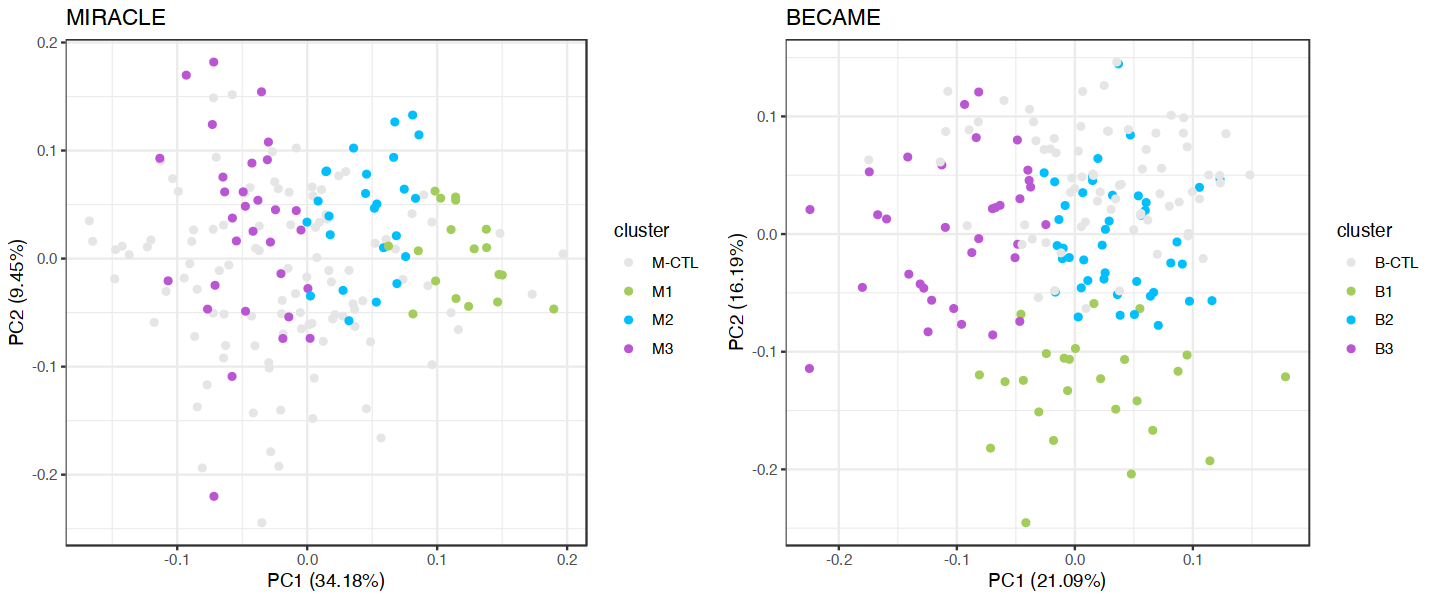

In [32]:
for(i in 1:ncol(miracle_num)){miracle_num[,i]=as.numeric(miracle_num[,i])}
pca = prcomp(scale(log(t(miracle_num))))
print(dim(pca$x))
meta$cluster[meta$cluster=='MNA']='M-CTL'
p1 = autoplot(pca,data=meta[colnames(miracle_num),],col='cluster')+theme_bw()+scale_color_manual(values=c('grey90','darkolivegreen3','deepskyblue','mediumorchid'))

became_num=became_num[,-ncol(became_num)]
became_meta = meta[which(!is.na(meta$cluster) & meta$cohort=='BECAME'),]
became_meta = became_meta[rownames(became_meta)%in%colnames(became_num),]
became_num = became_num[,rownames(became_meta)]
for(i in 1:ncol(became_num)){became_num[,i]=as.numeric(became_num[,i])}
pca = prcomp(scale(log(t(became_num))))
print(dim(pca$x))
meta$cluster[meta$cluster=='BCtrl']='B-CTL'
p2 = autoplot(pca,meta[colnames(became_num),],col='cluster')+scale_color_manual(values=c('grey90','darkolivegreen3','deepskyblue','mediumorchid'))+theme_bw()

options(repr.plot.width = 12, repr.plot.height = 5)

cowplot::plot_grid(p1+ggtitle('MIRACLE'),p2+ggtitle('BECAME'),ncol=2)

In [33]:
became_num=t(became_num)
miracle_num=t(miracle_num)

merged = data.frame(rbind(became_num,miracle_num))
merged$group = 'BECAME'
merged[rownames(merged)[rownames(merged)%in%colnames(miracle)],'group'] = 'MIRACLE'
p1 = autoplot(prcomp(merged[,-ncol(merged)]),data=merged,col='group')+theme_bw()


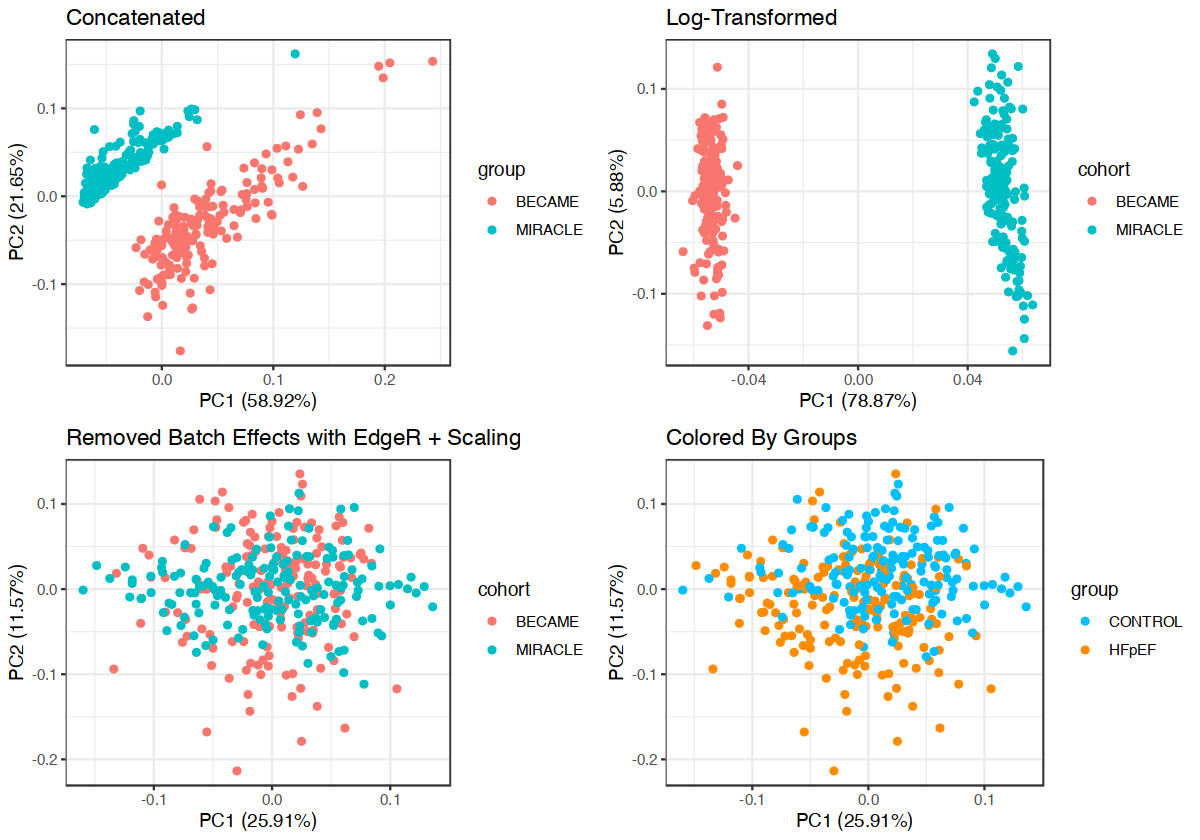

In [34]:

# log-transform
merge_scaled = log(merged[,-ncol(merged)])
# remove batch reffect
m = limma::removeBatchEffect(t(merge_scaled),batch = merged$group)

# Scale Data
meta$group[meta$group=='Ctrl'] = 'CONTROL'
meta$group[meta$group=='FEP'] = 'HFpEF'
scaled_df = data.frame(scale(t(m)))
rows = rownames(meta)[rownames(meta) %in% rownames(scaled_df)]

p2 = autoplot(prcomp(merge_scaled[,-ncol(merge_scaled)]),data=merged[rownames(merge_scaled),],col='group')+theme_bw()+labs(col='cohort')
p3 = autoplot(prcomp(scaled_df[rows,]),data=meta[rows,],col='cohort')+theme_bw()
p4 = autoplot(prcomp(scaled_df[rows,]),data=meta[rows,],col='group')+theme_bw()+scale_color_manual(values=c('deepskyblue','darkorange'))


options(repr.plot.width = 10, repr.plot.height = 7)

cowplot::plot_grid(p1+ggtitle('Concatenated'),
                   p2+ggtitle('Log-Transformed'),
                   p3+ggtitle('Removed Batch Effects with EdgeR + Scaling'),
                   p4+ggtitle('Colored By Groups'),ncol=2)

In [12]:
pca_pre = data.frame(prcomp(scale(merge_scaled[,-ncol(merge_scaled)]))$x)
pca = data.frame(prcomp(scaled_df[rows,])$x)
pca_toplot = cbind(pca_pre[rows,c('PC1','PC2')],pca[rows,c('PC1','PC2')],meta[rows,'cohort'])

In [13]:
colnames(pca_toplot) = c('PC1.pre','PC2.pre','PC1.post','PC2.post','cohort')

In [14]:
pca$cohort = meta[rows,'cohort']

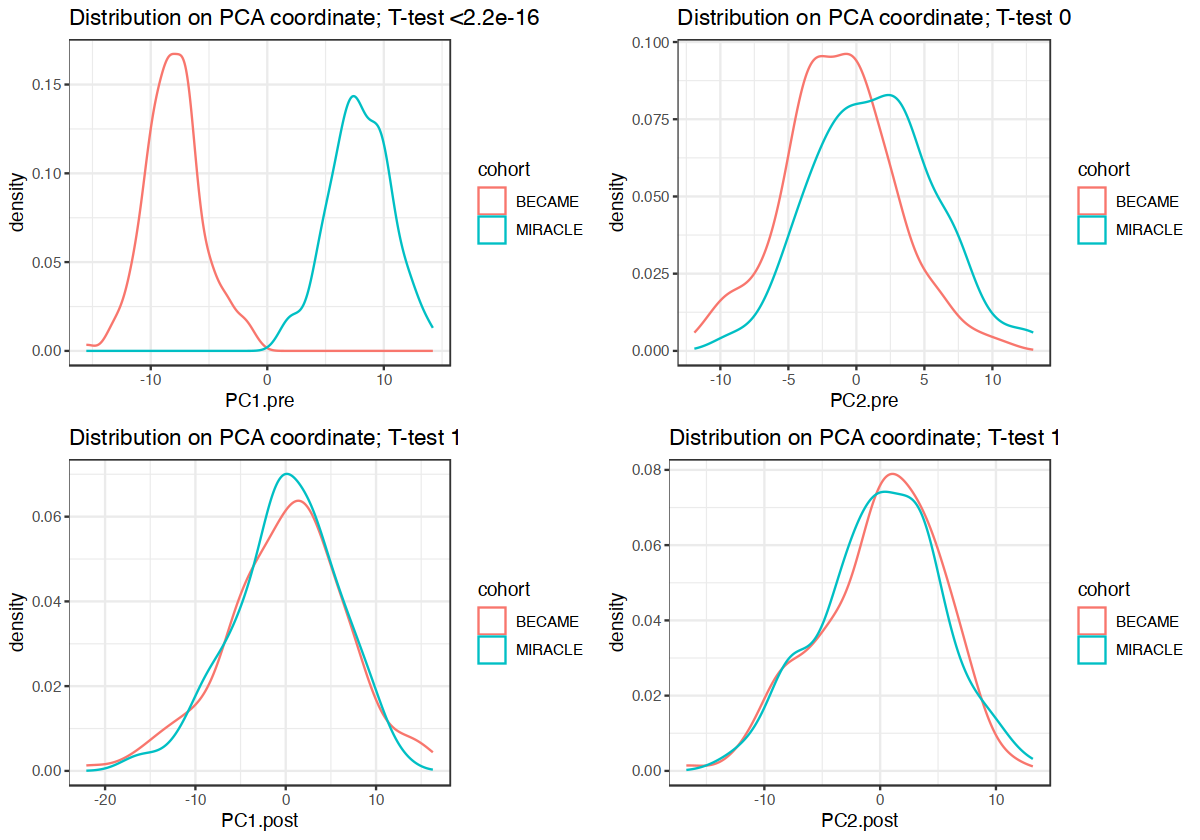

In [15]:
p1 = ggplot(pca_toplot,aes(PC1.pre,col=cohort))+geom_density()+theme_bw()+ggtitle(paste0('Distribution on PCA coordinate; T-test <2.2e-16'))
p2 = ggplot(pca_toplot,aes(PC2.pre,col=cohort))+geom_density()+theme_bw()+ggtitle(paste0('Distribution on PCA coordinate; T-test ',round(t.test(pca_toplot$PC2.pre~pca_toplot$cohort)$p.value,digits=3)))

p3 = ggplot(pca_toplot,aes(PC1.post,col=cohort))+geom_density()+theme_bw()+ggtitle(paste0('Distribution on PCA coordinate; T-test ',round(t.test(pca_toplot$PC1.post~pca_toplot$cohort)$p.value,digits=3)))
p4 = ggplot(pca_toplot,aes(PC2.post,col=cohort))+geom_density()+theme_bw()+ggtitle(paste0('Distribution on PCA coordinate; T-test ',round(t.test(pca_toplot$PC2.post~pca_toplot$cohort)$p.value,digits=3)))

cowplot::plot_grid(p1,p2,p3,p4,ncol=2)

In [16]:
t.test(pca_toplot$PC1.post~pca_toplot$cohort)


	Welch Two Sample t-test

data:  pca_toplot$PC1.post by pca_toplot$cohort
t = -6.8564e-16, df = 340.23, p-value = 1
alternative hypothesis: true difference in means between group BECAME and group MIRACLE is not equal to 0
95 percent confidence interval:
 -1.315792  1.315792
sample estimates:
 mean in group BECAME mean in group MIRACLE 
        -3.690375e-16          8.962077e-17 


In [17]:
write.table(scaled_df[rows,],'../data/merged_dataset_newNorm.csv',quote=F,sep=',')
write.table(meta[rows,],'../data/merged_dataset_meta.csv',quote=F,sep=',')